# Text Halo

A text halo draws an outline around text, improving readability when labels are placed on top of colorful, textured, or busy plot areas.

Use `halo_width` to set the halo width and `halo_color` to set the halo color. A halo is rendered only when `halo_width > 0`; setting `halo_color` on its own has no visible effect. When `halo_color` is omitted, the panel background color is used (falling back to the plot background color when the panel draws no rectangle).


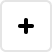
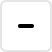
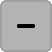
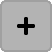
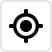
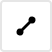
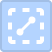
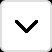
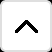
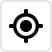
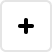
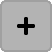
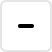
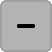
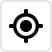
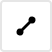
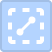
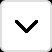
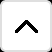
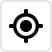

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd

from lets_plot import *
from lets_plot.bistro.corr import corr_plot

LetsPlot.setup_html()

## Basic usage: text visible on any background

In [2]:
bg = pd.DataFrame({'xmin': [0, 0.7, 2.3], 'xmax': [0.7, 2.3, 3], 'ymin': 0, 'ymax': 1, 'fill': ['white', 'black', 'white']})

p = (
    ggplot()
    + geom_rect(aes(xmin='xmin', xmax='xmax', ymin='ymin', ymax='ymax', fill='fill'), data=bg, size=0)
    + scale_fill_identity()
    + xlim(0, 3) + ylim(0, 1) + ggsize(560, 240) + theme_void()
)

p += geom_text(
    x=1.5, y=0.7, label='black text with white halo',
    color='black',
    halo_color='white',           # <-- adding halo
    halo_width=2.2,               # <-
    size=22,
    fontface='bold')

p += geom_text(
    x=1.5, y=0.3, label='white text with black halo',
    color='white',
    halo_color='black',           # <-- adding halo
    halo_width=2.2,               # <-
    size=22,
    fontface='bold')
p

In [3]:
mpg = (
    pd.read_csv('https://raw.githubusercontent.com/JetBrains/lets-plot-docs/master/data/mpg.csv')
    .drop(columns=['Unnamed: 0'])
)

mpg_num = mpg.select_dtypes(include=np.number)
mpg_num.head(3)

,displ,year,cyl,cty,hwy
0,1.8,1999,4,18,29
1,1.8,1999,4,21,29
2,2.0,2008,4,20,31


## Text labels with and without halo

The halo helps preserve the label color while separating the text from nearby points.

In [4]:
# Prepare a dataset and a base plot
sample = (
    mpg.sort_values('hwy', ascending=False)
    .groupby('manufacturer', as_index=False)
    .head(1)
)

scatter_base = (
    ggplot(mpg, aes('displ', 'hwy'))
    + geom_point(aes(color='class'), size=4, alpha=.75)
    + ggsize(520, 360)
)

base_plot = scatter_base + theme_minimal()

label_options = dict(
    data=sample,
    size=7,
    check_overlap=True,
)

In [5]:
no_halo = (
    base_plot
    + geom_text(
        aes(label='manufacturer'), 
        color='pen',
        **label_options
       )
    + ggtitle('Labels without halo')
)

with_halo = (
    base_plot
    + geom_text(
        aes(label='manufacturer'), 
        color='pen',
        halo_width=1.5,                      # <--- adding a halo
        **label_options
       )
    + ggtitle('Labels with halo')
)

gggrid([no_halo, with_halo], ncol=1)

Because `halo_color` defaults to the theme's background color, the *same* labeled plot stays readable when the flavor changes: the `pen` text and its halo both follow the theme, with no manual color tuning.

In [6]:
gggrid([with_halo + flavor_high_contrast_dark() + ggtitle('Dark flavor')])

### Inverting Theme Colors

You can invert the color pairing by using `color='paper'` for the text and `halo_color='pen'` for the outline.

In [7]:
inverted_labels = (
    base_plot
    + geom_text(
        aes(label='manufacturer'),
        color='paper',
        halo_width=1.7,
        halo_color='pen',
        **label_options
    )
    + ggtitle('Text in paper, halo in pen')
)

gggrid([inverted_labels + theme_grey(), inverted_labels + flavor_high_contrast_dark()], ncol=1)

## Correlation Plot Labels

In a correlation plot the labels sit on top of the colored tiles, not on the plot background, so the default halo does not blend into the surface behind the text the way it does over an empty panel. Instead, it acts as a contrasting outline around each label.

Pairing `color='pen'` with the default halo is convenient here: the text takes the theme's foreground color while the halo takes the theme's `paper` color, so the two always contrast and the labels stay readable in both light and dark flavors. The first two examples demonstrate this.

In [8]:
corr_plots = gggrid([
    corr_plot(mpg_num)
    .tiles()
    .labels(color='pen')
    .build() + ggtitle('No halo'),

    corr_plot(mpg_num)
    .tiles()
    .labels(color='pen', halo_width=1.3)
    .build() + ggtitle('With halo')
])
corr_plots

In [9]:
corr_plots + flavor_darcula()

If you choose a fixed text color instead, you may also need to set `halo_color` explicitly so the halo contrasts with both the labels and the tiles.

In [10]:
gggrid([
    corr_plot(mpg_num)
    .tiles()
    .labels(color='white')
    .build() + ggtitle('White text'),

    corr_plot(mpg_num)
    .tiles()
    .labels(color='white', halo_width=1.6)             # <-- halo_color is missing
    .build() + ggtitle('Default halo_color'),

    corr_plot(mpg_num)
    .tiles()
    .labels(color='white', halo_width=1.6, halo_color='gray40')
    .build() + ggtitle('Adjusted halo_color'),
]) 

## Repelled Labels on a Map

For geographic labels, a light halo separates place names from map outlines and neighboring markers while keeping the map styling simple.

In [11]:
base_url = 'https://raw.githubusercontent.com/JetBrains/lets-plot-kotlin/master/docs/examples/shp/'
world_gdf = gpd.read_file(base_url + 'naturalearth_lowres/naturalearth_lowres.shp')
cities_gdf = gpd.read_file(base_url + 'naturalearth_cities/naturalearth_cities.shp')

(
    ggplot()
    + geom_map(map=world_gdf, fill='light_green/0.3')
    + geom_point(map=cities_gdf, color='dark_slate_gray', size=3)
    + geom_text_repel(
        aes(label='name'),
        data=cities_gdf,
        color='dark_slate_gray',
        seed=42,
        max_iter=200,
        halo_width=2.0,
        halo_color='white'
    )
    + coord_map(xlim=[-10.5, 44.0], ylim=[37.0, 60.5])
    + theme(axis='blank', panel_grid='blank')
    + ggsize(800, 600)
)